## Importar Librerías

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install torch
# Machine Learning & Deep Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# GenAI

from transformers import pipeline

sns.set_theme(style="darkgrid")
import warnings
warnings.filterwarnings('ignore')

## Integración de las 3 Bases de Datos (Data Wrangling)
Vamos a cruzar los datos de los mundiales con los partidos para saber si el equipo local era el anfitrión (lo cual da una ventaja enorme).


In [9]:
# Cargar datos
matches = pd.read_csv(r'C:\Users\pablo\Desktop\Data Science\Final Project - World Cup\Final-Project---World-Cup\db\WorldCupMatches.csv').dropna(how='all')
cups = pd.read_csv(r'C:\Users\pablo\Desktop\Data Science\Final Project - World Cup\Final-Project---World-Cup\db\WorldCups.csv')
players = pd.read_csv(r'C:\Users\pablo\Desktop\Data Science\Final Project - World Cup\Final-Project---World-Cup\db\WorldCupPlayers.csv')

# Limpieza básica de nombres
matches['Home Team Name'] = matches['Home Team Name'].str.replace('rn">', '').str.strip()
matches['Away Team Name'] = matches['Away Team Name'].str.replace('rn">', '').str.strip()

# 1. Cruzar Matches con Cups para obtener el país anfitrión (Host)
matches = matches.merge(cups[['Year', 'Country']], on='Year', how='left')
matches.rename(columns={'Country': 'Host Country'}, inplace=True)

# 2. Análisis rápido de Players (Top Jugadores con más partidos en la historia)
top_players = players['Player Name'].value_counts().head(10)

print(f"Partidos: {matches.shape[0]}, Mundiales: {cups.shape[0]}, Registros de Jugadores: {players.shape[0]}")
matches.head(2)

Partidos: 852, Mundiales: 20, Registros de Jugadores: 37784


,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,...,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials,Host Country
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,...,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX,Uruguay
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,...,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL,Uruguay


## EDA Avanzado (Visualizaciones de Nivel Presentación)

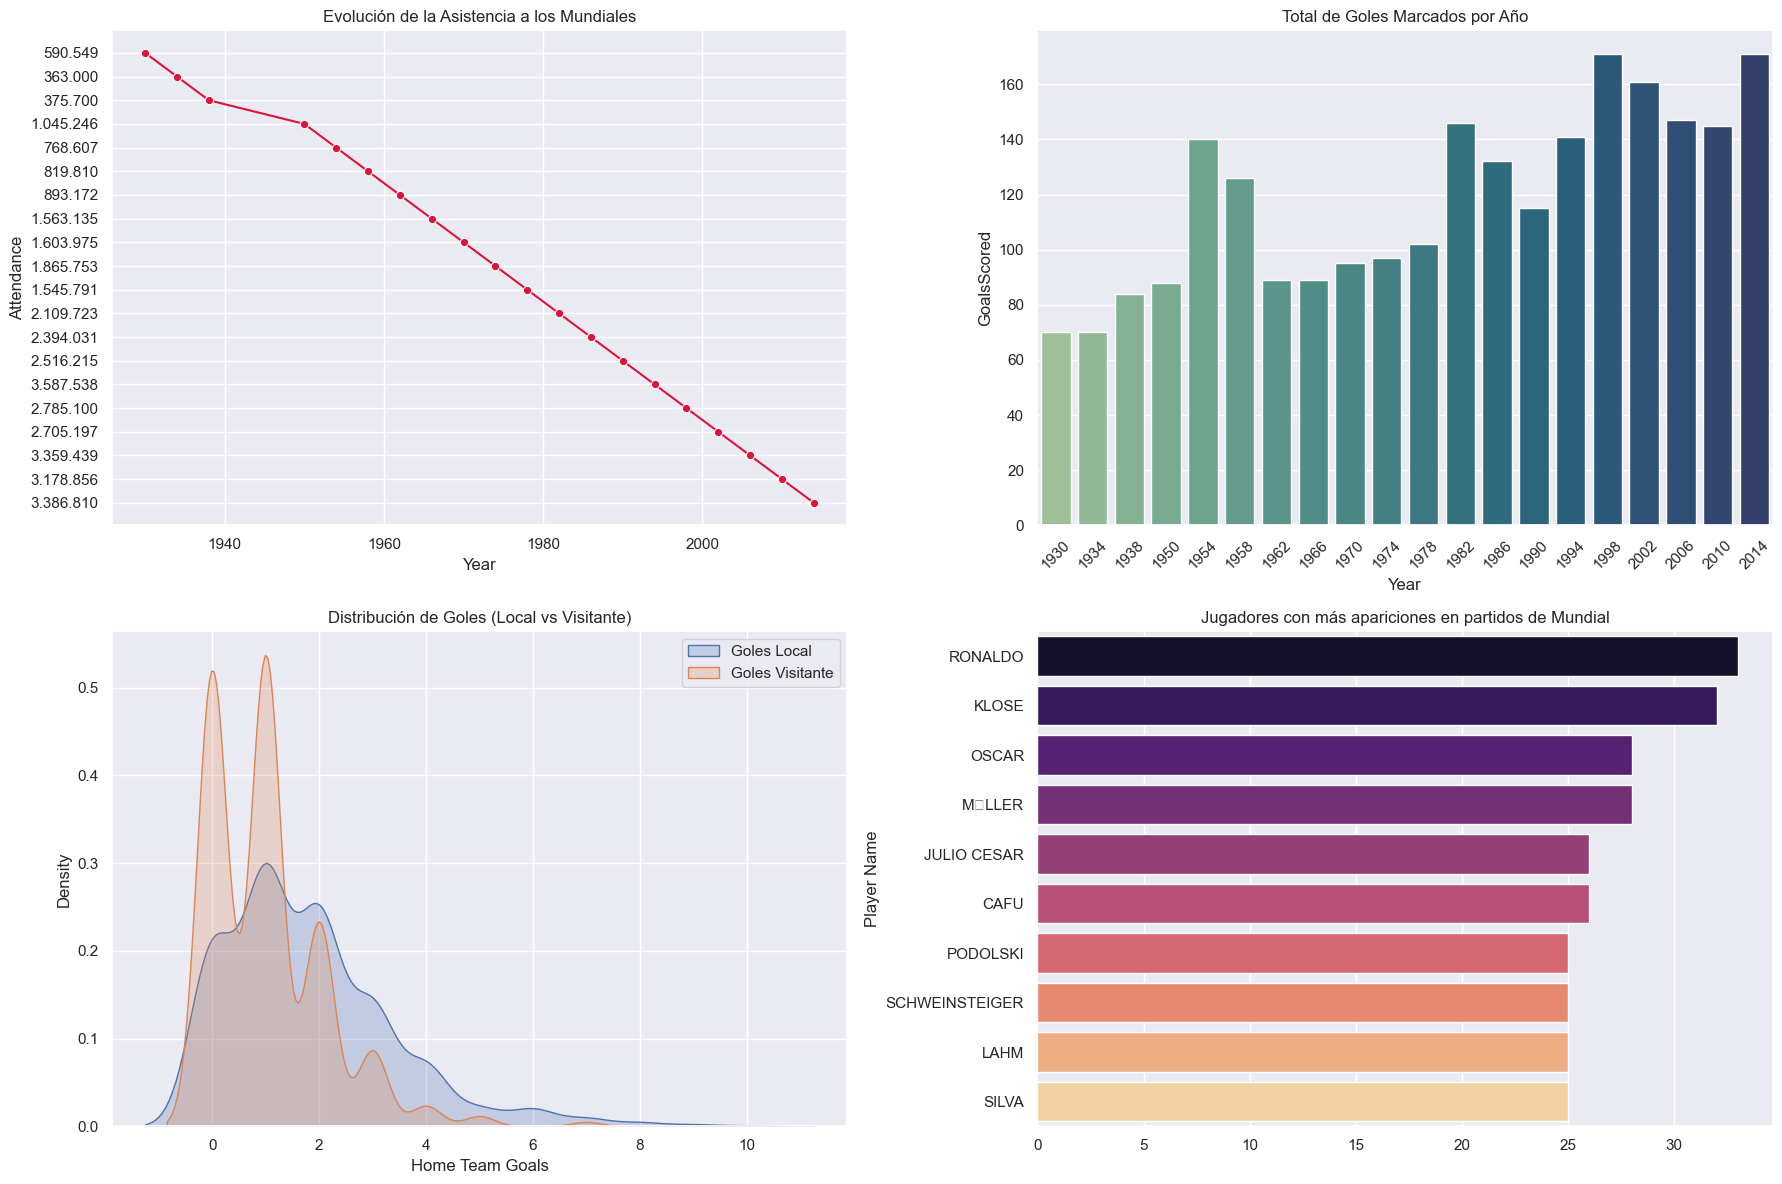

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Evolución de Asistencia en los Mundiales
sns.lineplot(data=cups, x='Year', y='Attendance', marker='o', ax=axes[0, 0], color='crimson')
axes[0, 0].set_title('Evolución de la Asistencia a los Mundiales')

# 2. Goles por Mundial
sns.barplot(data=cups, x='Year', y='GoalsScored', ax=axes[0, 1], palette='crest')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_title('Total de Goles Marcados por Año')

# 3. Distribución de Goles Locales vs Visitantes
sns.kdeplot(matches['Home Team Goals'], fill=True, label='Goles Local', ax=axes[1, 0])
sns.kdeplot(matches['Away Team Goals'], fill=True, label='Goles Visitante', ax=axes[1, 0])
axes[1, 0].set_title('Distribución de Goles (Local vs Visitante)')
axes[1, 0].legend()

# 4. Top 10 Jugadores con más apariciones en partidos
sns.barplot(x=top_players.values, y=top_players.index, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Jugadores con más apariciones en partidos de Mundial')

plt.tight_layout()
plt.show()

## Feature Engineering Avanzado (El secreto para subir el Accuracy)
Un modelo no aprende solo con el nombre del país. Necesita saber qué tan bueno es el país. Vamos a crear variables matemáticas.

In [11]:
# Definir target: 2 (Gana Local), 1 (Empate), 0 (Gana Visitante)
def determine_winner(row):
    if row['Home Team Goals'] > row['Away Team Goals']: return 2
    elif row['Home Team Goals'] < row['Away Team Goals']: return 0
    else: return 1

matches['Target'] = matches.apply(determine_winner, axis=1)

# Crear variables de peso: ¿Es el equipo local el anfitrión? (Ventaja de localía)
matches['Is_Host'] = (matches['Home Team Name'] == matches['Host Country']).astype(int)

# Diferencia histórica de goles (Aproximación de la fuerza del equipo)
matches['Goal_Difference'] = matches['Home Team Goals'] - matches['Away Team Goals']

# Preparar el Dataset Final para el Modelo
df_ml = matches[['Home Team Name', 'Away Team Name', 'Is_Host', 'Target']].copy()

le = LabelEncoder()
# Codificamos todos los equipos en el mismo espacio numérico
all_teams = pd.concat([df_ml['Home Team Name'], df_ml['Away Team Name']]).unique()
le.fit(all_teams)

df_ml['Home_ID'] = le.transform(df_ml['Home Team Name'])
df_ml['Away_ID'] = le.transform(df_ml['Away Team Name'])

# Variables de entrada y salida
X = df_ml[['Home_ID', 'Away_ID', 'Is_Host']]
y = df_ml['Target']

# Escalado de datos (Vital para Redes Neuronales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Entrenamiento Pro (XGBoost vs Deep Learning)

--- 1. Entrenando XGBoost (Machine Learning Avanzado) ---
XGBoost Accuracy: 0.480

--- 2. Entrenando Red Neuronal Artificial (Deep Learning) ---
Deep Learning Accuracy: 0.561


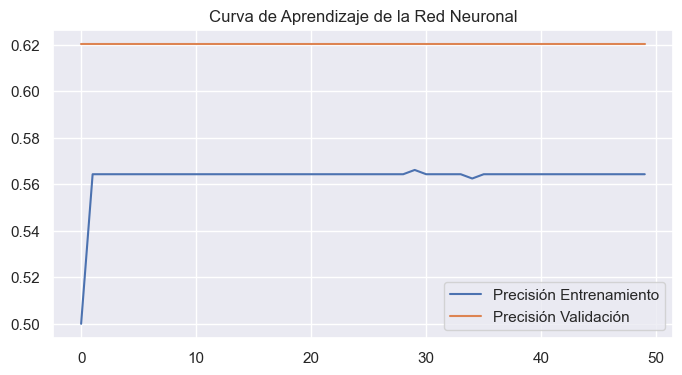

In [12]:
print("--- 1. Entrenando XGBoost (Machine Learning Avanzado) ---")
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.3f}")

print("\n--- 2. Entrenando Red Neuronal Artificial (Deep Learning) ---")
# Arquitectura de la Red Neuronal (MLP)
dl_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2), # Previene el sobreajuste (overfitting)
    Dense(32, activation='relu'),
    Dense(3, activation='softmax') # 3 salidas: Gana, Empata, Pierde
])

dl_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenar la red neuronal (silenciamos la salida para no llenar la pantalla)
history = dl_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

# Evaluar
loss, dl_acc = dl_model.evaluate(X_test, y_test, verbose=0)
print(f"Deep Learning Accuracy: {dl_acc:.3f}")

# Plot del entrenamiento de la Red Neuronal
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Precisión Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión Validación')
plt.title('Curva de Aprendizaje de la Red Neuronal')
plt.legend()
plt.show()

## GenAI (Transformers de Hugging Face)
Para el requisito de GenAI, vamos a usar un LLM Open Source para generar comentarios automáticos (como si fuera un periodista deportivo) basados en los resultados del dataset.

In [13]:
# Usamos un pipeline de generación de texto ligero (GPT-2) de HuggingFace
print("Cargando modelo GenAI (puede tardar un minuto la primera vez)...")
from transformers import pipeline
generador = pipeline('text-generation', model='distilgpt2') # Usa distilgpt2 que es más rápido

# Tomamos un partido al azar de nuestro dataset
ejemplo = matches.iloc[12] # Partido al azar
local = ejemplo['Home Team Name']
visitante = ejemplo['Away Team Name']
goles_l = ejemplo['Home Team Goals']
goles_v = ejemplo['Away Team Goals']

# Creamos un prompt con los datos estructurados
prompt = f"In the FIFA World Cup match between {local} and {visitante}, the final score was {goles_l} - {goles_v}. The match was very exciting because"

print(f"\nDatos reales del partido: {local} {goles_l} - {goles_v} {visitante}")
print("Generando crónica con GenAI...")

# Llamamos al generador UNA SOLA VEZ con los parámetros correctos
resultado_genai = generador(
    prompt, 
    max_new_tokens=50, 
    num_return_sequences=1, 
    pad_token_id=50256
)

print("\nCrónica Generada por IA:")
print(resultado_genai[0]['generated_text'])



Cargando modelo GenAI (puede tardar un minuto la primera vez)...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Datos reales del partido: Paraguay 1.0 - 0.0 Belgium
Generando crónica con GenAI...

Crónica Generada por IA:
In the FIFA World Cup match between Paraguay and Belgium, the final score was 1.0 - 0.0. The match was very exciting because it was played in the first half of the match.



The play was very difficult because the team had to lose to a team that had the ball on their possession and in the middle of the pitch, in the first half, which


In [14]:
import joblib
joblib.dump(xgb_model, 'modelo_fifa.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("Archivos exportados exitosamente")

Archivos exportados exitosamente
